# Project Group: 10 

Members: Mulham Omar, Jalissa Rattan, Benjamin Rider, Hinke Verbaan, Lois Zhao

# 1. Research background - Introduction
Public transportation plays a vital role in the daily lives of many people. To understand what influences how often buses are used, we investigated three key factors: age, gender, and population density. By examining how each of these variables affects bus ridership, we can gain insights that may help improve the planning and design of bus routes to better serve community needs. For this project, we analyzed ridership data collected by the Massachusetts Bay Transportation Authority (MBTA).

# 2. Research Objective

The main objective of this study is to analyze how demographic factors influence bus ridership patterns in Boston. By understanding these relationships, the study aims to provide insights that could support data-driven decisions for improving public transportation planning and accessibility.

The Sub-questions are:

- Examine the relationship between the median age of local block groups and bus stop ridership.
- Analyze how the gender distribution of local block groups affects bus stop ridership.
- Evaluate the impact of population density on bus stop ridership.

# Hypotheses

Prior to analysing the data the following hypotheses were established, based on general rationale. The actual results of the analysis will support or revoke these hypotheses:

- Areas in Boston with higher population density will have higher bus ridership rates.
    - Reasoning: More people living in a small area means greater demand for public transit.
- Areas with a higher proportion of females will show different ridership levels than areas with a higher proportion of males.
    - Reasoning: Gender may influence travel patterns due to work, safety, or lifestyle differences.
- Neighborhoods with a lower median age (younger populations) will have higher bus ridership.
    - Reasoning: Younger individuals are more likely to use public transport for school, work, and social activities.

# 3. Contribution Statement

**Mulham**: Coding/visualization transformed Data, References, finalizing the notebook (template & report)

**Jalissa**: Make graphs and graphs description, coding for visualisation, writing of the text and helping creating the final notebook

**Benjamin**: Collected dataset, background research, transformation data

**Hinke**: Transformation data, writing of text, making graphs, rewriting code, discussion, data pipeline

**Lois**: Statistical analysis, data pipeline, writing of the text, appendix


**Link to github**: https://github.com/Mulhamomar/TIL6022_group10



# 4. Data Used

Dataset 1: MBTA bus ridership by Time Period, Season, Route/Line, and Stop. (2025, March 20). https://mbta-massdot.opendata.arcgis.com/datasets/7acd353c1a734eb8a23caf46a0e66b23_0/explore?filters=eyJzZWFzb24iOlsiRmFsbCAyMDI0IiwiRmFsbCAyMDIwIl19

Dataset 2: Mass Government. (2022). MassGIS Data: 2020 U.S. Census [Dataset]. https://www.mass.gov/info-details/massgis-data-2020-us-census

Dataset 3: MBTA bus ridership by Time Period, Season, Route/Line, and Stop. (2025, March 20). https://mbta-massdot.opendata.arcgis.com/datasets/7acd353c1a734eb8a23caf46a0e66b23_0/explore?filters=eyJzZWFzb24iOlsiRmFsbCAyMDI0IiwiRmFsbCAyMDIwIl19

Dataset 4: Mass Government. (2017). MassGIS Data: MBTA Bus Routes and Stops [Dataset]. https://www.mass.gov/info-details/massgis-data-mbta-bus-routes-and-stops

# 5. Data Pipeline

① Input data: We extract the datasets from the websites (mentioned in Data Used). 

Step 1: Demographic data from Dataset 3 is paired with its Census Block Group shapefile from Dataset 2. 
Step 2: A spatial join is performed in ArcGIS Pro to pair each bus stop with its Census Block Group
Step 3: Each entry in Dataset 1 is paired with demographic data for its respective bus stop.
Step 4: The table is exported from ArcGIS Pro into an XLSX file, then exported to a CSV using Excel.

② Transform data: In this step we select and transform useful data from the datasets. Below here, we describe how we get the dataframe for the analysis analyse. 


- Bus_Ridership: **Ben can you add how you did this in gis?** In dataset 1, the usage is devided by time of day, for our research question we need to calculate the average use of a busstop in general **per day**. Therefore from database 1 we add average_ons and average_off per stop_ID this is devided by the amount of times that this specific stop_ID was in the database. This transformation will be done in python.

                       Busridership per day for specific busstop == total_trips/amount of entries in stop_ID

Where total_trips is:

                                     total_flow == [average_ons + average_offs] * total_trips


All of the datatypes below were transformed via the computerprogramm arcgis. With intersecting the busstop location(dataset 1) and the local block group (dataset 2). From here the data was translated into a csv file. 

- median_age: The median age in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- gender_distribution(Percent Male/Percent Female): The gender distribution in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- population_density: The total population (Total_Popu) of a single block group we can get this directly from dataset 2. The area of a single block group (Block_Area **what is the metric**) can be derived from dataset 3. This transformation will be done in python.

                                         Population density == Total_Popu / Block_Area


③ Analyze data: For every research question the same statistical analysis is used, as we are just switching what we are comparing the ridership data to (Median_Age, Gender_Distribution and Population_Density). This will be done by using the linear regrssion, Spearman correlation and Anova analysis respectively for each  sub-question in python.

In [1]:
# All packages used for this research
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm

#packages for the map
import geopandas as gpd
import plotly.graph_objects as go
from shapely import wkt
from shapely.geometry import LineString, MultiLineString, Point

# Data Visulaization

The interactive map below is used as an aiding visulaization of the transformed Data. When Hovering over a bus stop, the corresponding data for the bus stop will be shown.

In [4]:
def map(database):
    # Load Stops
    stops_info = pd.read_csv(database)

    # Parse WKT(Well-Known Text) geometry into Shapely Points
    stops_info['geometry'] = stops_info['geometry'].apply(wkt.loads)

    # Create a GeoDataFrame for stops with (CRS:Coordinate Reference System)
    #EPSG Geodetic Parameter Dataset, which is a giant registry of CRS definitions
    stops_gdf = gpd.GeoDataFrame(
        stops_info, 
        geometry='geometry',
        crs='EPSG:26986'  # Massachusetts State Plane
    )

    # Reproject stops to WGS84[standard GPS mapping] (lat/lon)
    stops_gdf = stops_gdf.to_crs(epsg=4326)

    # Extract lat/lon from the reprojected points
    stops_gdf['lon'] = stops_gdf['geometry'].apply(lambda p: p.x)
    stops_gdf['lat'] = stops_gdf['geometry'].apply(lambda p: p.y)

    #Filter columns for hover
    hover_cols = [col for col in stops_info.columns if not col.startswith('Unnamed') and col != 'geometry']

    #Load Routes
    routes = gpd.read_file("MBTABUSROUTES_ARC.shp")

    # If CRS is not set, manually assign EPSG:26986
    if routes.crs is None:
        routes = routes.set_crs(epsg=26986)

    # Reproject to WGS84 (EPSG:4326) for lat/lon
    routes = routes.to_crs(epsg=4326)

    #Extract coordinates from LineString / MultiLineString
    def get_coords(geom):
        lons, lats = [], []
        if isinstance(geom, LineString):
            x, y = geom.xy
            lons.extend(x)
            lats.extend(y)
        elif isinstance(geom, MultiLineString):
            for line in geom.geoms:
                x, y = line.xy
                lons.extend(x)
                lats.extend(y)
        return lons, lats

    # Create Plotly figure
    fig = go.Figure()

    # Add routes
    for _, row in routes.iterrows():
        lons, lats = get_coords(row.geometry)
        fig.add_trace(go.Scattermapbox(
            lon=lons,
            lat=lats,
            mode='lines',
            line=dict(width=2, color='blue'),
            name=row.get('ROUTE_NAME', 'Route'),
            showlegend=False
        ))

    # Add stops
    fig.add_trace(go.Scattermapbox(
        lon=stops_gdf['lon'].tolist(),
        lat=stops_gdf['lat'].tolist(),
        mode='markers',
        marker=dict(size=6, color='red'),
        customdata=stops_info[hover_cols].values,
        hovertemplate='<br>'.join([f'<b>{col}</b>: %{{customdata[{i}]}}' for i, col in enumerate(hover_cols)]) + '<extra></extra>',
        name='Stops',
        showlegend=True
        ))

    # fix Layout
    # Compute map center based on reprojected stops
    center_lat = stops_gdf['lat'].mean()
    center_lon = stops_gdf['lon'].mean()

    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox=dict(
            zoom=10,
            center=dict(lat=center_lat, lon=center_lon)
        ),
        height=700,
        title="MBTA Bus Routes and Stops",
        margin={"r":0,"t":30,"l":0,"b":0}
    )
    fig.show()

map("TIL6022datageo.csv") #printing of defined function map


ImportError: The 'read_file' function requires the 'pyogrio' or 'fiona' package, but neither is installed or imports correctly.
Importing pyogrio resulted in: dlopen(/opt/anaconda3/envs/TILPython/lib/python3.13/site-packages/pyogrio/_vsi.cpython-313-darwin.so, 0x0002): Library not loaded: @rpath/libnetcdf.19.dylib
  Referenced from: <A2860E87-DCA6-3E1C-869C-97EF1B16E899> /opt/anaconda3/envs/TILPython/lib/libgdal.32.3.6.2.dylib
  Reason: tried: '/opt/anaconda3/envs/TILPython/lib/libnetcdf.19.dylib' (no such file), '/opt/anaconda3/envs/TILPython/lib/python3.13/site-packages/pyogrio/../../../libnetcdf.19.dylib' (no such file), '/opt/anaconda3/envs/TILPython/lib/python3.13/site-packages/pyogrio/../../../libnetcdf.19.dylib' (no such file), '/opt/anaconda3/envs/TILPython/bin/../lib/libnetcdf.19.dylib' (no such file), '/opt/anaconda3/envs/TILPython/bin/../lib/libnetcdf.19.dylib' (no such file), '/usr/local/lib/libnetcdf.19.dylib' (no such file), '/usr/lib/libnetcdf.19.dylib' (no such file, no

# 6. Analysis data
**A. Transformation of data**

In [3]:
# All packages used for this research
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
# from statsmodels.nonparametric.smoothers_lowess import lowess
# from statsmodels.formula.api import rlm
# from statsmodels.stats.outliers_influence import variance_inflation_factor

Through the analysis multiple functions will be defined. These functions will be shown here, as a quick overview.

In [5]:
#In this function the transformations are done on the data
def calculate_columns(df):
    df['pop_density'] = df['total_pop']/df['bg_area'] #Calculates population density (people per km2)
    df['total_trips'] = (df['num_trips']*5).where(df['day_type_name'] == 'weekday', df['num_trips']) #Finds number of trips per week
    df['total_ons'] = df['total_trips']*df['average_ons'] #Finds total ons per week
    df['total_offs'] = df['total_trips']*df['average_offs'] #Finds total offs per week
    df['average_flow'] = df['average_ons']+df['average_offs'] #Finds average flow
    df['total_flow'] = df['total_ons']+df['total_offs'] #Finds total flow per week
    #df.to_csv(file) #Update CSV
    agg_functions = {'stop_name': 'first', 'total_trips': 'sum','total_flow':'sum', 'median_age': 'first', 'pop_density' : 'first', 'percent_male': 'first'} #transformations done in the aggregate funciton
    df_new = df.groupby(df['stop_id']).aggregate(agg_functions) #transforming the data
    df_new['average_flow'] = df_new['total_flow']/df_new['total_trips']
    df_new.to_csv(new_file)
    df = df_new

#This function makes scatterplots of the df data set. 
def scatter(x,y,h,v,a,b,c): 
    #Down below we defined a function to make scatterplots of the df data set. 
    #Follow the instructions down below to use the defined function.
    # for x and y set variables 
    #for h and v set untis for variables
    #for a and b set place in figure
    #for c set title(string)
    ax[a,b].set_xlabel(x +" "+ h)
    ax[a,b].set_ylabel(y +" "+ v)
    x = df[x]
    y = df[y]
    slope, intercept = np.polyfit(x, y, 1)
    line = slope * x + intercept
    ax[a,b].plot(x, y, 'b.', markersize=2)
    ax[a,b].plot(x, line ,'r')
    #visualisation
    ax[a,b].set_title(c)
    ax[a,b].grid()
   
#This function makes scatter plots with LOESS line to check the linearity.   
def linearity_check(df, vars_to_plot, y_var, title_prefix):
    fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(6*len(vars_to_plot), 5))
    
    for i, var in enumerate(vars_to_plot):
        sns.regplot(
            x=var, 
            y=y_var, 
            data=df, 
            lowess=True, 
            ax=axes[i],
            scatter_kws={"s":20, "alpha":0.6},
            line_kws={"color":"red"}
        )
        axes[i].set_title(f"{title_prefix} vs {var}")

    plt.tight_layout()
    plt.show()

#This function makes a histogram and QQ plot to analyse normality of residuals.
def normality(model):
    #Put in for x, the model name that comes out of this function (model1 = sm.OLS(Y1_log, X_total).fit(cov_type='HC3')) 
    #in the multiple linear regression.

    #Create figure
    fig, axes = plt.subplots(1,3, figsize=(15,5))

    #Normality of residuals histogram
    residuals = model.resid
    

    sns.histplot(residuals, bins = 30, kde=True, color='blue',ax = axes[0])
    axes[0].set_title("Residuals Histogram")
    plt.title("Histogram of Residuals (transformed model)")
    plt.xlabel("Residuals")

    #Normality of residuals QQ plot
    fitted = model.fittedvalues
    
    sm.qqplot(residuals, line='45', fit=True, ax = axes[1])
    axes[1].set_title("QQ Plot of Residuals (transformed model)")
    
    #check the homoscedasticity
    sns.scatterplot(x=fitted, y=residuals, alpha=0.6, ax = axes[2])
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title("Residuals vs Fitted")
    axes[2].set_xlabel("Fitted Values")
    axes[2].set_ylabel("Residuals")

#This function makes boxplots of the df data set.
def boxplot(bins, labels, x, h, t):
    # x for variable
    # t for title(string)
    # h unit for x
    grouped = df['grouped'] = pd.cut(df[x], bins=bins, labels=labels, right=False)
    fig, axes = plt.subplots(1,3, figsize=(16,4))
    #boxplot without outliers
    out = sns.boxplot(x= 'grouped', y='average_flow', data=df, showfliers=False, ax = axes[0])
    out.set_title(t + ' without outliers')
    out.set_xlabel(h)
    out.set_ylabel('per week')
    #boxplot with outliers
    no_out = sns.boxplot(x= grouped, y='average_flow', data=df, showfliers=True, ax = axes[1])
    no_out.set_title(t + ' with outliers')
    no_out.set_xlabel(h)
    out.set_ylabel('per week')
    #boxplot over the whole population
    whole = sns.boxplot(y='average_flow',data=df, showfliers=False, ax = axes[2])
    whole.set_xlabel(" ")
    whole.set_title("Whole population without outliers")
    plt.show()

In [6]:
file = 'TIL6022Data.csv'
new_file = 'TIL6022aggdata.csv'
df = pd.read_csv(file) #Read CSV
def calculate_columns(df):
    df['pop_density'] = df['total_pop']/df['bg_area'] #Calculates population density (people per km2)
    df['total_trips'] = (df['num_trips']*5).where(df['day_type_name'] == 'weekday', df['num_trips']) #Finds number of trips per week
    df['total_ons'] = df['total_trips']*df['average_ons'] #Finds total ons per week
    df['total_offs'] = df['total_trips']*df['average_offs'] #Finds total offs per week
    df['average_flow'] = df['average_ons']+df['average_offs'] #Finds average flow
    df['total_flow'] = df['total_ons']+df['total_offs'] #Finds total flow per week
    
    #df.to_csv(file) #Update CSV
    agg_functions = {'stop_name': 'first', 'total_trips': 'sum','total_flow':'sum', 'median_age': 'first', 'pop_density' : 'first', 'percent_male': 'first'} #transformations done in the aggregate funciton
    df_new = df.groupby(df['stop_id']).aggregate(agg_functions) #transforming the data
    df_new['average_flow'] = df_new['total_flow']/df_new['total_trips']
    df_new.to_csv(new_file)

/var/folders/r3/ps4tjr5s3zv8ngmz8lkpxrtc0000gn/T/ipykernel_47615/2366739684.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file) #Read CSV


**B. General Graphs after the data transformation**

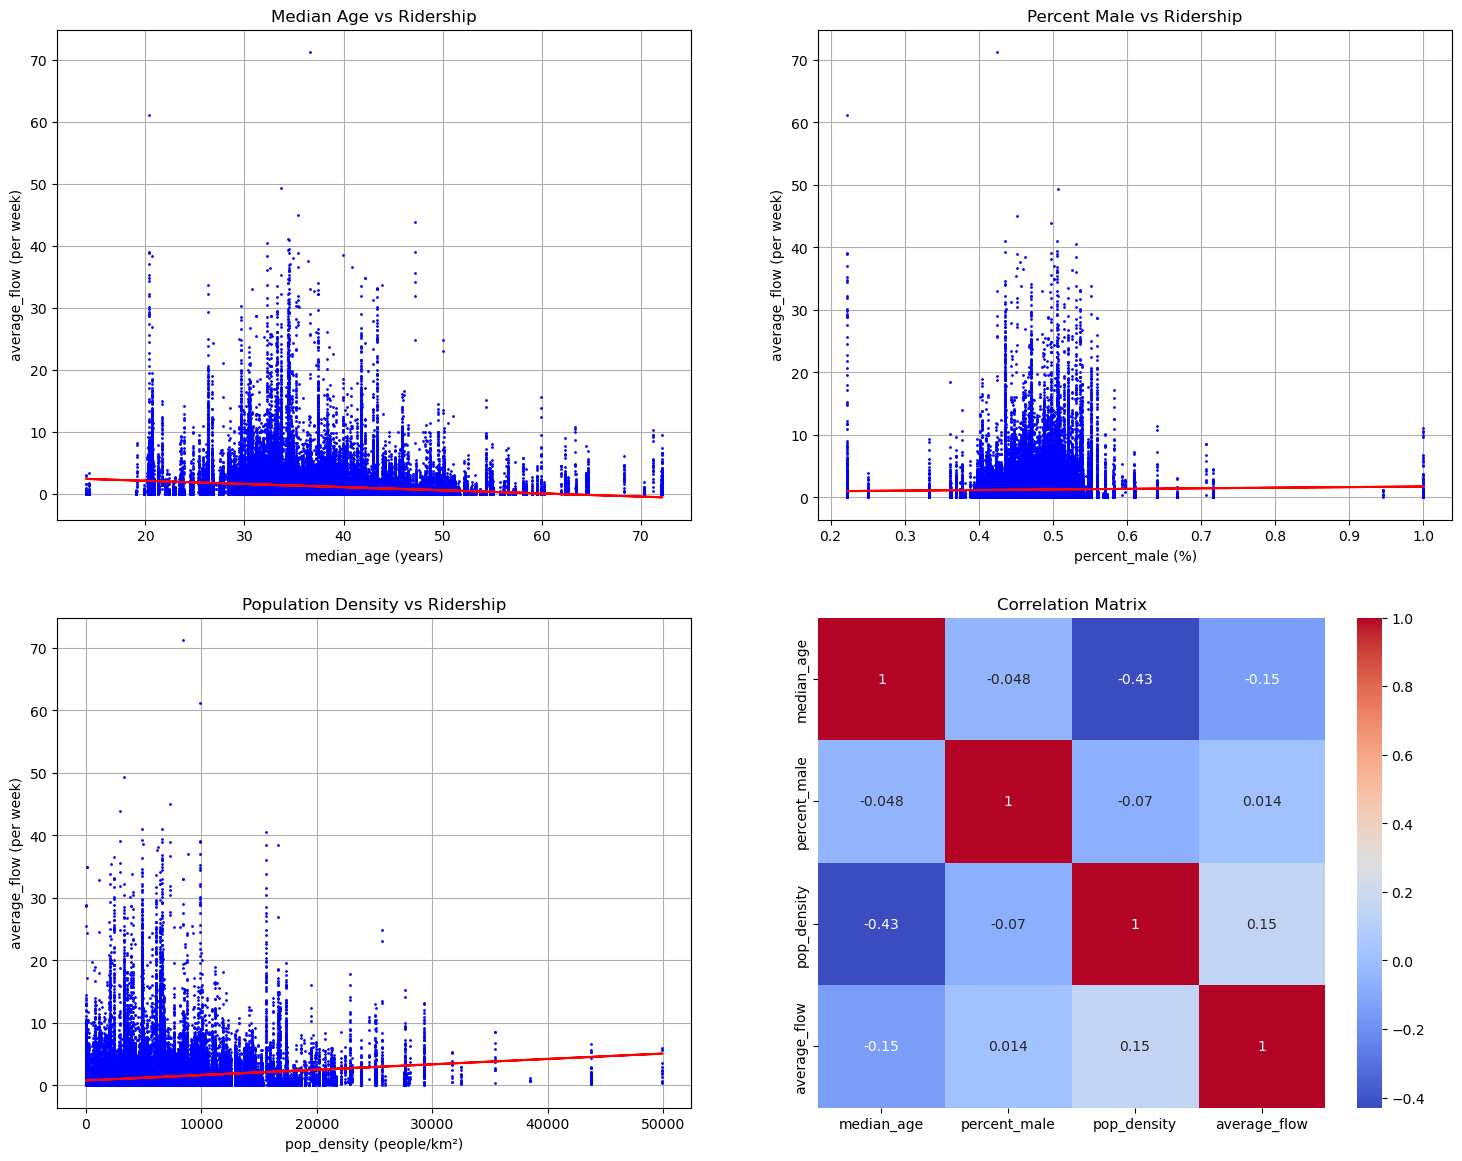

In [7]:
#using defenition scatter to print scatter plots
fig, ax = plt.subplots(2, 2, figsize=(18, 14)) #set layout for define function.
scatter('median_age', 'average_flow', '(years)', '(per week)', 0, 0, 'Median Age vs Ridership') #previously defined function
scatter('percent_male', 'average_flow', '(%)','(per week)', 0, 1,'Percent Male vs Ridership') #previously defined function
scatter('pop_density', 'average_flow', '(people/km²)','(per week)', 1, 0,'Population Density vs Ridership') #previously defined function

#Correlation Matrix
correlation = df[['median_age', 'percent_male', 'pop_density', 'average_flow']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=ax[1, 1])
ax[1, 1].set_title('Correlation Matrix')

plt.show()

**Explanation of the general graphs**

The figure presents three scatter plots and one correlation matrix (heatmap), aiming to explore how demographic characteristics (such as median age, gender distribution, or population density) relate to bus ridership levels in Boston.
Each blue point represent a bus stop, while the red regression line shows the overall direction of the relationship.

In figure 1, Median Age vs Ridership, reveals a slightly negative trend, areas with older populations tend to have slightly lower average weekly passenger flows. However, the spread of the data and the flat regression line suggest that median age alone is not a strong predictor of ridership.

In figure 2, Percent Male vs Ridership, shows no clear pattern (almost no visible relationship). The data points are widely scattered without a clear pattern, and the regression line remains almost flat, showing that the gender distribution has little influence on how often people use the bus.

In figure 3, Population Density vs Ridership, displays a clear upward trend. On the x-axis it is visible that the population density increases and the average weekly ridership tends to rise. This aligns with expectations, as densely populated areas generally have more potential bus users.

In figure 4, a Correlation Matrix is created. This confirms the visual findings numerically (summarizes and compare correlations between all variables at once). The population density shows the strongest positive correlation with ridership (r ≈ 0.15), while median age is slightly negatively coorelated (r ≈ - 0.15). The other variables show negligible correlations, reinforcing that demographic factors alone do not explain ridership patterns very well.

Overall, the graphs show that population density is the key demographic factor influencing bus ridership in Boston, while age and gender play only minor roles.

**C. Statistical analysis**

To analyze to what extent three demographic variables (X1-median_age, X2-pecent_male and X3-pop_density) affect bus stop use (Y1-total flow and Y2-average flow), multiple linear regression is considered to build the mathematical model.

For model 1, histograms are used to check distributions of independent and dependent variables. According to distributions, transform right-skewed variables into log format. Using linear regression model requires linearity, normality of residuals, homoscedasticity and samples independence. Therefore, drawing scatter plot with LOESS line, histogram and Q-Q plot to check those assumptions respectively. Transforming variables by feedback of plots, then get the multiple linear regression model 1: log⁡(Y_1+1)=β_0+β_1 〖(X_1-40)〗^2+β_2 |X_2-0.5|+β_3 [log(〖1+X〗_3)]^3+ε. As residuals’ points below reference line show discernible funnel shapes, heteroscedasticity-robust standard errors (HC3) were applied in the model establishment. More details of modeling could be seen in appendix.




**Multiple Linear Regression 1: Total flow**

In [8]:
#Transform variables based on regression plots in appendix
df["total_flow_log"] = np.log1p(df["total_flow"])
df["median_age_centered_sq"] = np.power(df["median_age"] - 40, 2)
df["percent_male_abs"] = np.abs(df["percent_male"] - 0.5)
df["pop_density_log_cub"] = np.power((np.log1p(df["pop_density"])), 3) 

#Multiple linear regression
X_total = df[["median_age_centered_sq", "percent_male_abs", "pop_density_log_cub"]]
X_total = sm.add_constant(X_total)  
Y1_log = df["total_flow_log"]

model1 = sm.OLS(Y1_log, X_total).fit(cov_type='HC3')
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:         total_flow_log   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     4688.
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:25:05   Log-Likelihood:            -1.9333e+05
No. Observations:              105918   AIC:                         3.867e+05
Df Residuals:                  105914   BIC:                         3.867e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

The multiple linear regression model 1, which is estimated with heteroscedasticity-robust (HC3) standard errors, indicates that all three demographic variables significantly predict the daily bus usage since p-values are all lower than 0.001. Additionally, all coefficients are positive, indicating all transformed variables have a statistically significant positive effect on log bus stop usage. For the whole model, R-square equals 0.126, which indicates the model can explain 12.6% of the variance in bus stop use. Although R-square is relatively low, many unobserved factors can influence bus stop usage. Nevertheless, the model is still considered reasonable and meaningful for analyzing the effects of these three demographic variables.

When analyzing the practical meaning of the model in real world, total_flow represents how many people in total used this stop per week (volume magnitude), in other words, it shows how popular the bus stop is in neighborhoods. The independent variable indicates the market size of bus stops, which can be used to estimate the bus resources supply, bus routes addition and regional transportation planning. The model indicates that both younger‐dominant and older‐dominant neighborhoods tend to generate more usage than areas with median age around 40. When the gender composition deviates more from 50% (either more male or more female), bus usage increases, which suggests that stops in more gender‐imbalanced neighborhoods tend to have higher bus usage. The positive coefficient indicates that bus usage increases rapidly with population density, and with log and cubic transformation, this captures a nonlinear accelerating effect: extremely dense areas produce disproportionately higher bus usage.

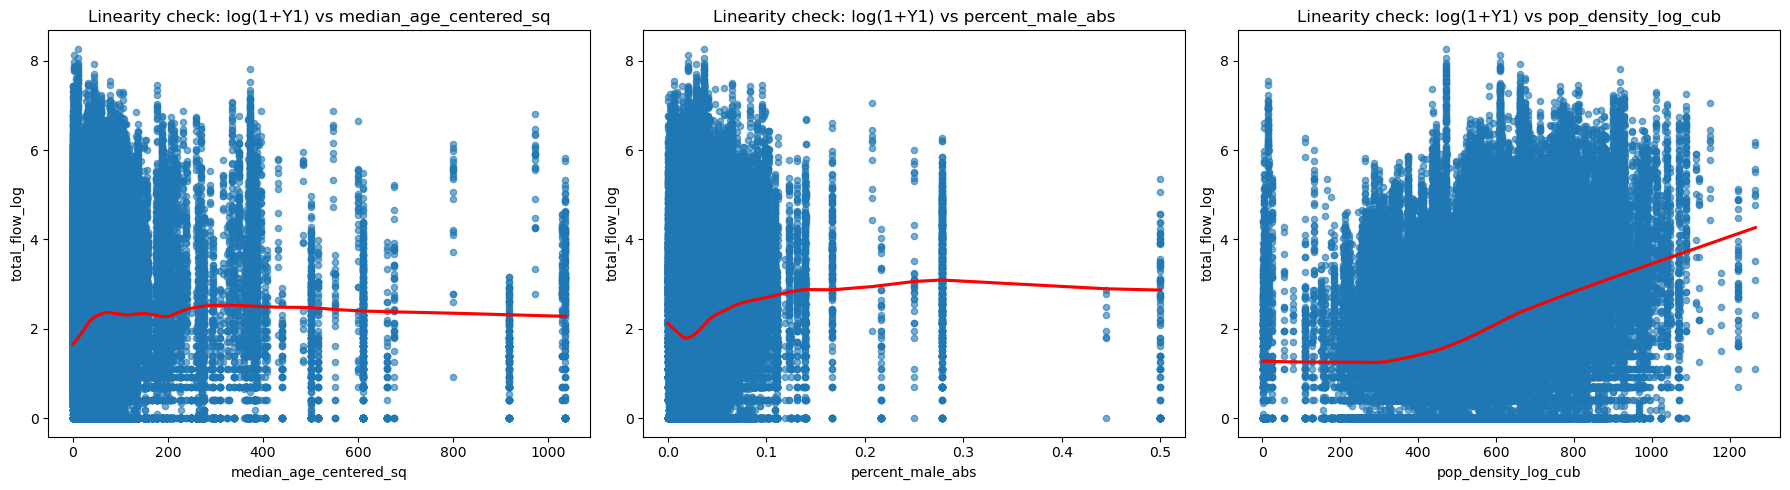

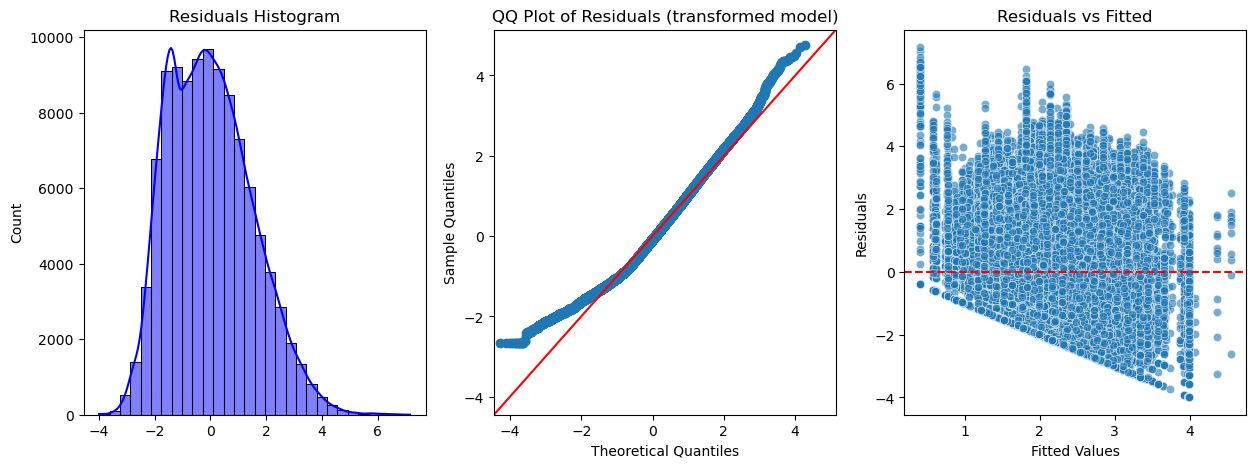

In [9]:
#assumption-check plots in model 1 (total_flow)
linearity_check(
    df,
    ["median_age_centered_sq", "percent_male_abs", "pop_density_log_cub"],
    "total_flow_log",
    "Linearity check: log(1+Y1)"
)
normality(model1) #previously defined function

**Results of assumption-check analysis**

In figure 1, 2 and 3, the LOESS lines are all approximately straight, so the linearity between independent and dependent variables exists. 

In figure 4, the distribution of residuals is approximately normal.

In figure 5, the blue line in QQ plot fits the diagonal line well. Based on the two plots, the normality of residuals in model 1 is satisfied. 

In figure 6, the residuals above the reference line distribute randomly while those below show a discernible funnel shape. Therefore, heteroscedasticity-robust standard errors (HC3) were applied in model establishment.

Overall, the multiple linear regression model 1 satisfies the key assumptions sufficiently, and can be considered valid for inference.

**Multiple Linear Regression 2: Average flow**


For establishing multiple linear regression model 2 for average flow, it follows the same steps as mpdel 1 and get the mathematical model:
log⁡(Y_2+1)=β_0+β_1 X_1+β_2 |X_2-0.5|+β_3 [log(〖1+X〗_3)]^3+ε. More details of modeling could be seen in appendix.

In [10]:
# Transform variables based on  regression plots in appendix
df["average_flow_log"] = np.log1p(df["average_flow"])
df["pop_density_log"] = np.log1p(df["pop_density"])
df["percent_male_abs"] = np.abs(df["percent_male"] - 0.5)  
df["pop_density_log_cub"] = np.power(df["pop_density_log"], 3) 


#Multiple linear regression
X_avg = df[["median_age", "percent_male_abs", "pop_density_log_cub"]]
X_avg = sm.add_constant(X_avg) 
Y2_log = df["average_flow_log"]

model2 = sm.OLS(Y2_log, X_avg).fit(cov_type='HC3')
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:       average_flow_log   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     3496.
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:25:15   Log-Likelihood:                -89375.
No. Observations:              105918   AIC:                         1.788e+05
Df Residuals:                  105914   BIC:                         1.788e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4896    

In model 2, all three demographic variables significantly predict the daily bus usage since p-values are all lower than 0.001. Additionally, coefficients of percent_male_abs and pop_density_log_cub are positive, indicating these two transformed variables have a statistically significant positive effect on log bus stop usage while the coefficient of median_age is negative. For the whole model, R-square equals 0.093, which indicates the model can explain 9.3% of the variance in bus stop use, which is considered meaningful and valid.

When analyzing the practical meaning of the model in real world, average_flow represents how many people used this stop per bus trip (utilization intensity), in other words, it shows how efficiently utilized for each bus arrival. The independent variable indicates utilization intensity of each bus, which can be used to estimate scheduling efficiency, crowd management and schedule optimization. The model indicates that higher median age is associated with lower per-trip usage while a higher deviation from gender balance is associated with higher average usage per trip. Population density also increases per-trip usage in an accelerating manner.

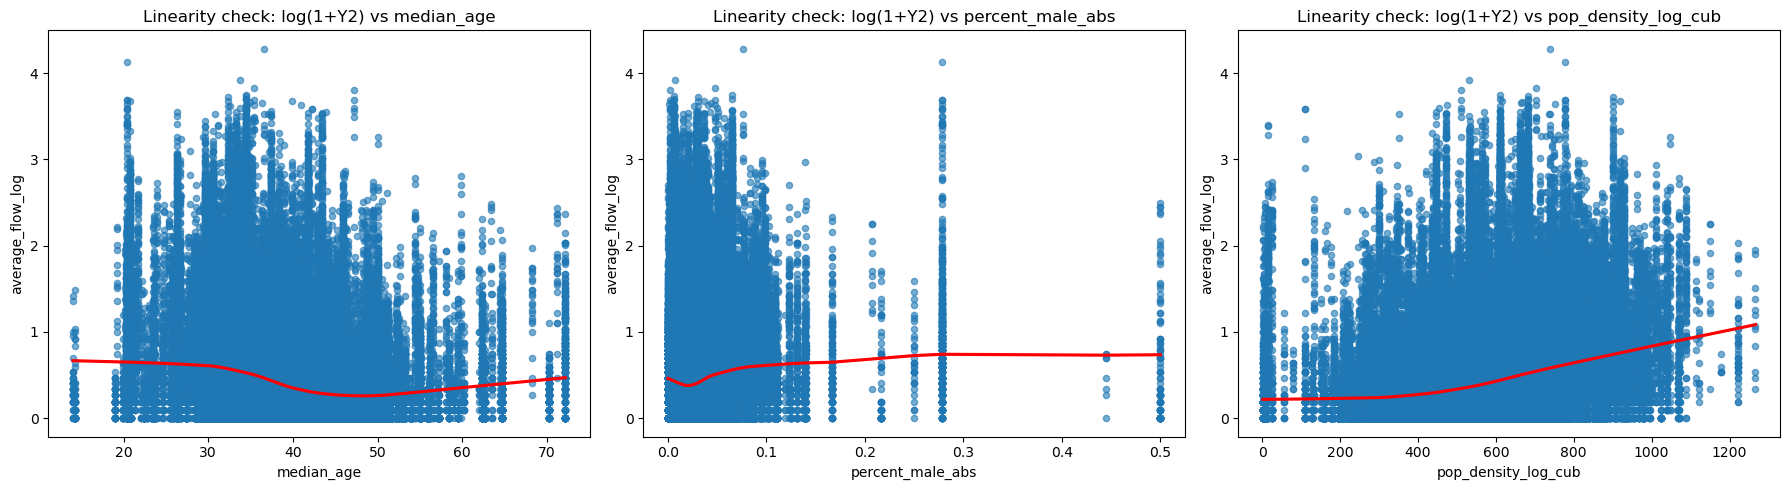

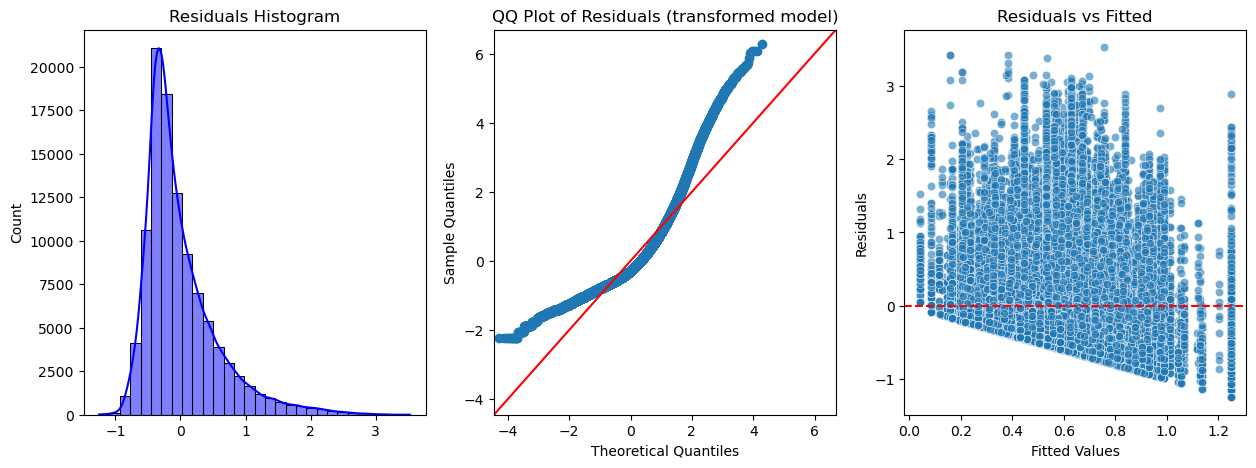

In [11]:
#assumption-check plots in model 2 (average_flow)
linearity_check(
    df,
    ["median_age", "percent_male_abs", "pop_density_log_cub"],
    "average_flow_log",
    "Linearity check: log(1+Y2)"
)
normality(model2) #previously defined function

**Results of assumption-check analysis**

In figure 1, 2 and 3, the LOESS lines are all approximately straight, so the linearity between independent and dependent variables exists. 

In figure 4, the distribution of residuals is approximately normal.

In figure 5, the blue line in QQ plot approximately fits the diagonal line. Based on the two plots, the normality of residuals in model 2 is satisfied. 

In figure 6, the residuals above the reference line distribute randomly while those below show a discernible funnel shape. Therefore, heteroscedasticity-robust standard errors (HC3) were applied in model establishment.

Overall, the multiple linear regression model 2 satisfies the key assumptions sufficiently, and can be considered valid for inference.

**D. Boxplot of the entire population**

The boxplot below shows a boxplot of population density, measured in people per square kilometer.
In this visualisation, the blue box represents the middle of the data (the range between the lower and upper quartiles). Inside the box, the horizontal line marks the median, the point where half of the observations are below and halve are above. The thin black lines extending from the box, often called whiskers shows the spread of the data excluding outliers. To the right the small circles indicate outliers (areas with unusually high population densities compared to the rest). The red dot present the mean population density.

In the shape of the plot, the distribution is right-skewed: most regions have relatively low population densities, while a few areas are extremely dense. This skewness causes the mean to be noticeably higher than the median, since those high-density outliers pull the average upward.


Axes(0.547727,0.11;0.352273x0.77)
Axes(0.125,0.11;0.352273x0.77)


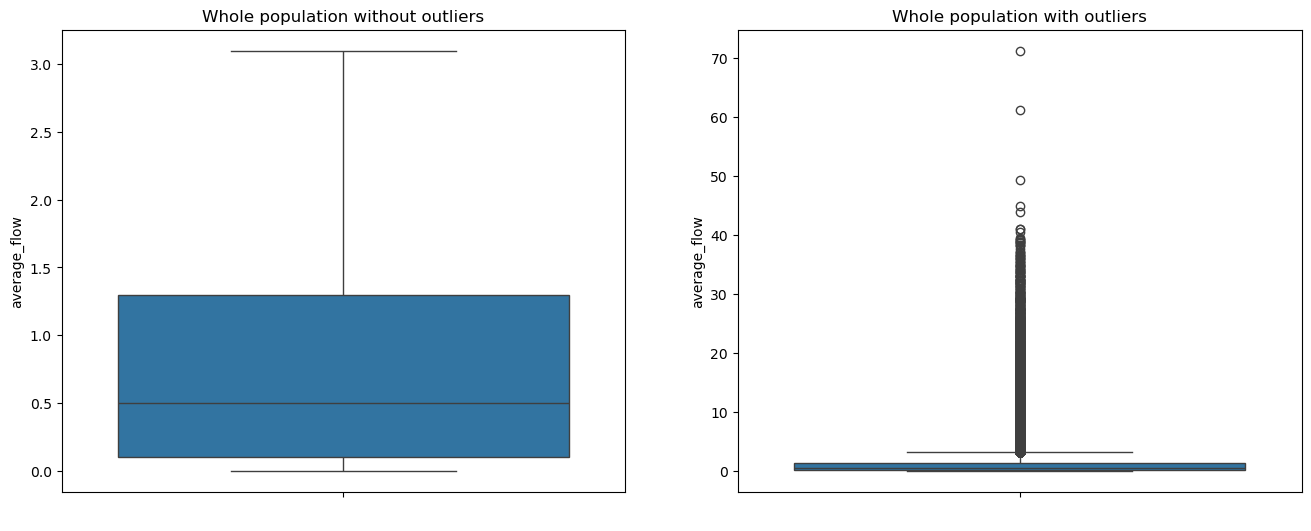

In [12]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
whole_outliers = sns.boxplot(y='average_flow',data=df, showfliers=False, ax = axes[0])
whole_outliers.set_xlabel(" ")
whole_outliers.set_title("Whole population without outliers")
whole_no_outliers = sns.boxplot(y='average_flow',data=df, showfliers=True, ax = axes[1])
whole_no_outliers.set_title("Whole population with outliers")
whole_no_outliers.set_xlabel(" ")

print(whole_no_outliers)
print(whole_outliers)

**Results about how to distribute the median age for the population using boxplot**

A boxplot is chosen to visualize the relationship between bus ridership and the median age of local block groups. This method provides a clear summary of the data distribution by displaying the median, interquartile range, and potential outliers for each age group. It allows for straightforward comparison between different demographic categories, making it easy to identify which median age ranges are associated with higher or lower bus ridership levels. Furthermore, the boxplot does not assume a normal distribution of data, which is beneficial since ridership values often vary widely and may be skewed. Overall, the boxplot offers an efficient and interpretable way to explore demographic influences on public transport usage.

The data contains median_age as a numerical value per bus stop. 
To use this in a boxplot analysis, this is divide it into groups (bins) so that the distribution of average_flow (bus use) per age category is seen.

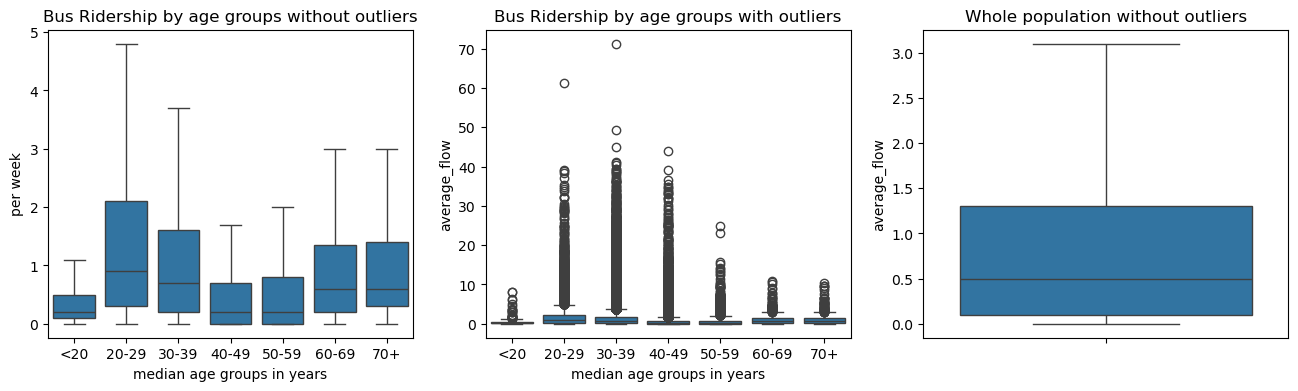

In [13]:
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
boxplot(bins, labels,'median_age', 'median age groups in years', 'Bus Ridership by age groups') #previously defined function

The boxplot above shows that the bus stops in younger neighborhoods (especially 20-29 and 30-39) have higher average passenger flow. Ridership tends to decrease gradually with age, meaning areas with older populations generally have less bus usage and there are a few extreme outliers exist stops with exceptionally high ridership which may correspond to key transport nodes or transfer points.

**Results of gender distribution (percent_male)**

This variable represents the percentage of men in a block group (between 0 and 1).
This is converted into categories per 10% or 5%, so that the impact on bus use can be seen.

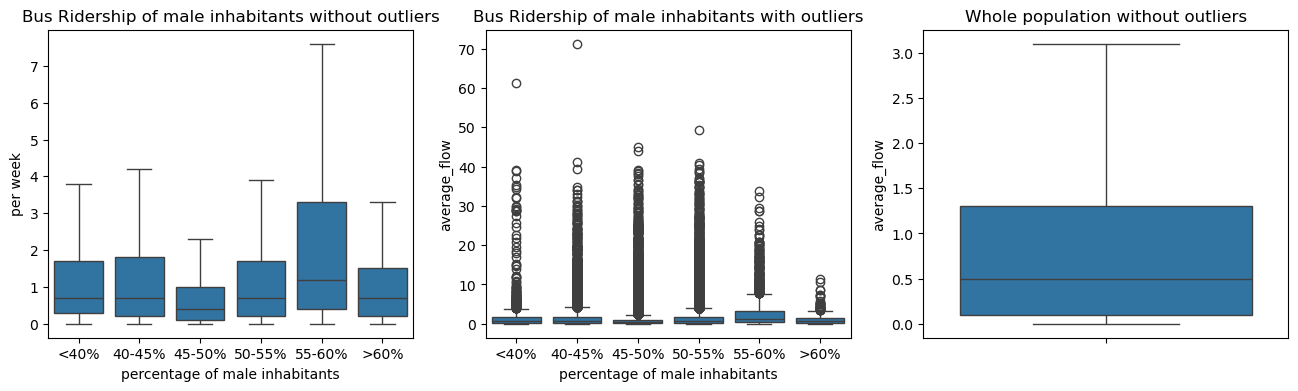

In [14]:
bins = [0, .4, .45, .5, .55, .6, 1.0]
labels = ['<40%', '40-45%', '45-50%', '50-55%', '55-60%', '>60%']
boxplot(bins, labels,'percent_male', 'percentage of male inhabitants', 'Bus Ridership of male inhabitants') #previously defined function

The boxplot shows that average bus use (measured as average flow per stop per week) varies only slightly accros block groups with different proportions of men. Generally the bus use tends to be somewhat higher in areas with a lower percentage of men (<45 %), and it appears to decrease gradually as the proportion of men increases. The variation within each category remains considerable. This pattern suggests that areas with relatively more woman may experience higher levels of bus use. Still, the differences between categories are modest, and the presence of numerous outliers indicates that gender composition alone does not fully explain bus use. Other demographic or contextual factors likely constribute as well.

**Results of Population Density**

This variable is usually skewed (some areas are very densely populated).
Therefore, we use a log transformation or quantile groups to ensure fair comparisons.

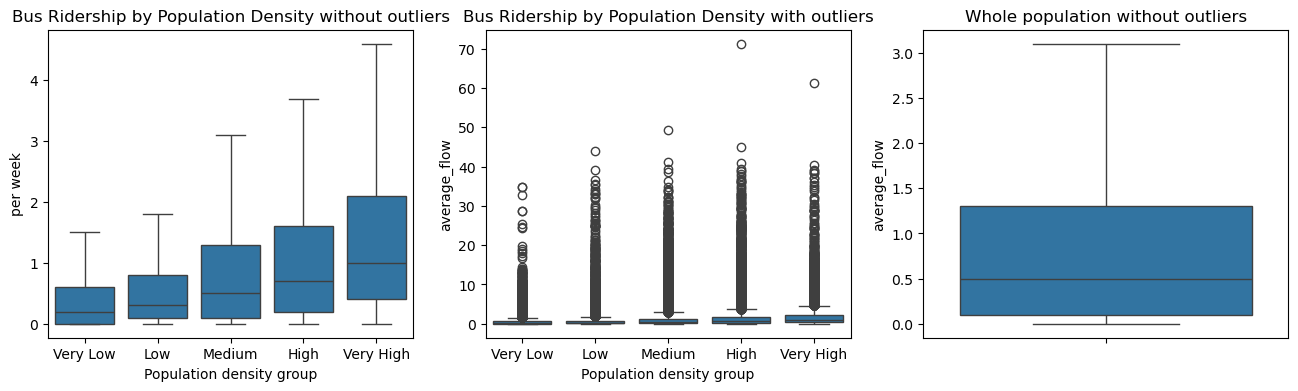

In [17]:
quartiles = df["pop_density_log"].quantile([.00, .20, .40, .60, .80,1.00]).tolist() #to make the bins
labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
boxplot(quartiles, labels,"pop_density_log", 'Population density group', 'Bus Ridership by Population Density') #previously defined function

The boxplot shows that average bus use (measured as average flow per stop per week) tends to increases slightly with higher population density. In areas with very low or low population density, average bus use is somewhat lower, while in densely populated areas (high and very high), both the median and dispersion of bus use are greater. This pattern is expected, as densely populated areas typically have higher demand for public transport and more residents living within walking distance of the bus stops. At the same time, the wide dispersion within each density group suggest that population density is not the only factor affecting bus use. Other meigborhood characteristics or aspects of transport provision are likely influential as well.

# 7. Conclusion
For all combinations of our independent and dependent variables, the regressions returned statistically significant results. Population density was positive correlated with both average and total flow, although less so with average flow. The local male proportion was also positively correlated with both average and total flow, again with a shallower regression line for average flow however. Median age had the most interesting results. When looking at total flow, the relationship is positive. However for average flow the result is negative. One possible explanation for this could be that average age is colinear with total population or population density. Looking at average flow which normalizes for total trips, a variable that is definitely colinear with population and population density, could reduce this effect.

# 8. Limitations and further research

**Datasets** - To conduct the research on the use of busstops for different demographs we needed to combine two datasets. The first was blockdata, in this we could see the demographic data of an area. The second data set was about the use of busstops themselves. Therefore the datasets were not both on the same geographical level and therefore the results will be limited in their use. 

**Further research** - As mentioned, we had a relatively narrow dataset to conduct this research. It would be interesting to obtain more data about the people that actually use the busstops. For example, look into the use of busstops thoughout the day and which demographics are using these services at those times. Furthermore, by looking into the data for the actual use for the busstops we can also correlate that with the demographic of the neighborhood. With doing this we can obtain if this paper is admissable or not.

**Final note** - As all of us were new to programming and python, therefore writing the code and understanding what we wanted out of that code often took a lot of time. For a next project we could dive deeper than we did now. 

# 10. Appendix
Statistical analysis

The detailed codes of modeling flow is shown as follows: 

Multiple Linear Congression 1 (Model 1: Y1-total_flow, X1-median_age, X2-percent_male, X3-pop_density)

       Variable         Mean
0    total_flow    34.121665
1  average_flow     1.239196
2    median_age    38.145254
3  percent_male     0.479577
4   pop_density  5383.398609


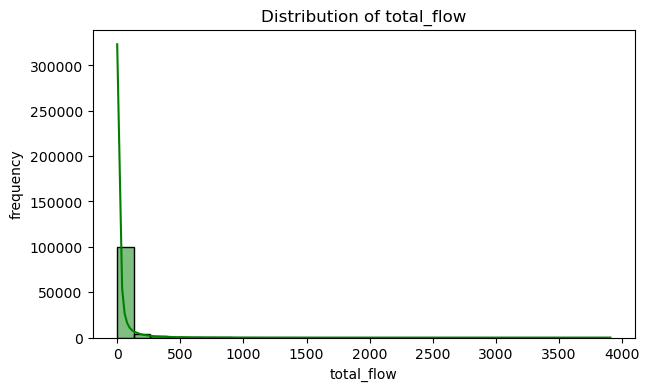

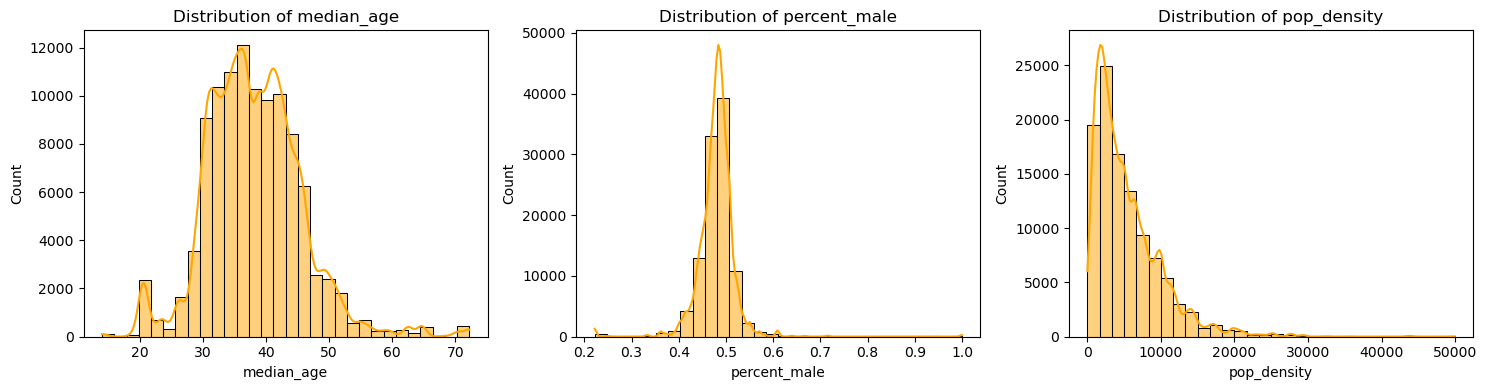

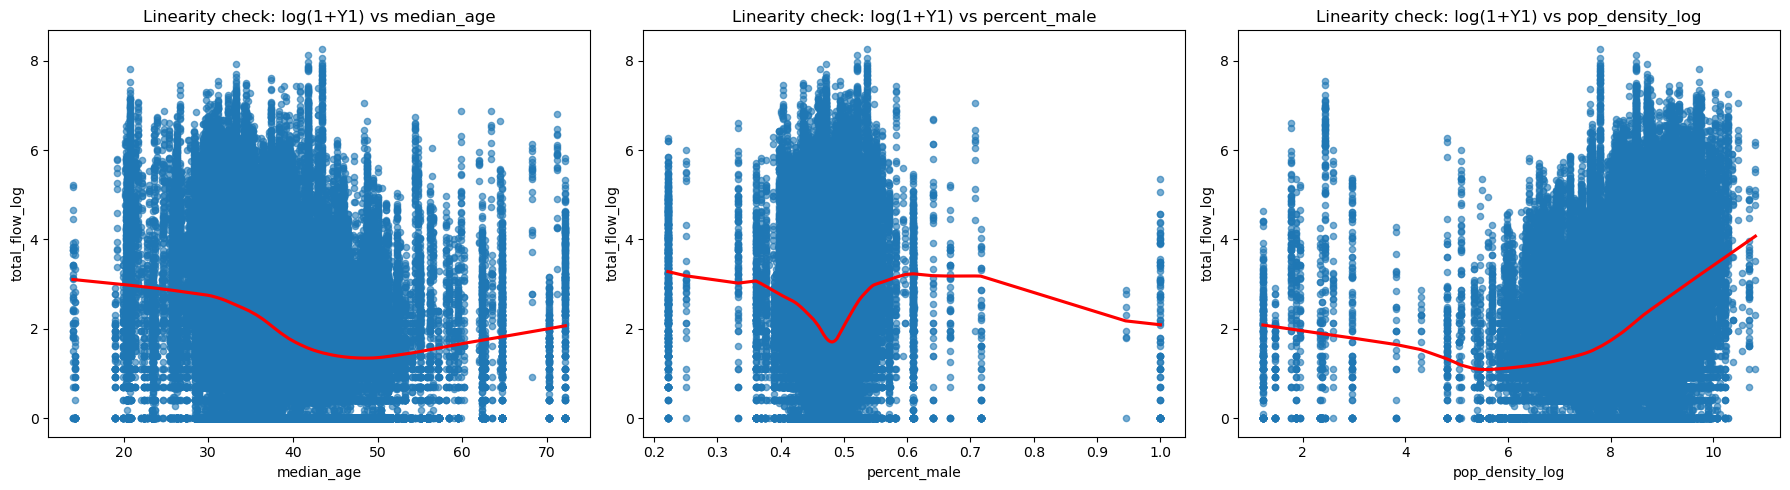

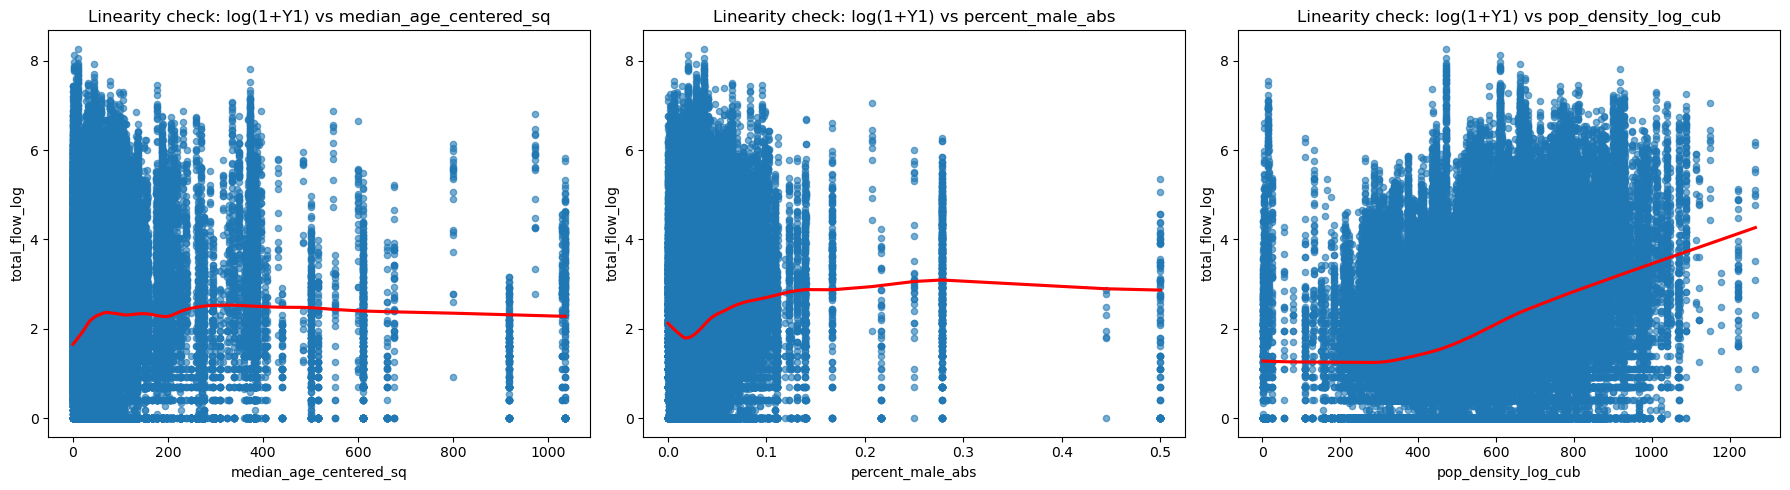

                            OLS Regression Results                            
Dep. Variable:         total_flow_log   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     4688.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:50:30   Log-Likelihood:            -1.9333e+05
No. Observations:              105918   AIC:                         3.867e+05
Df Residuals:                  105914   BIC:                         3.867e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

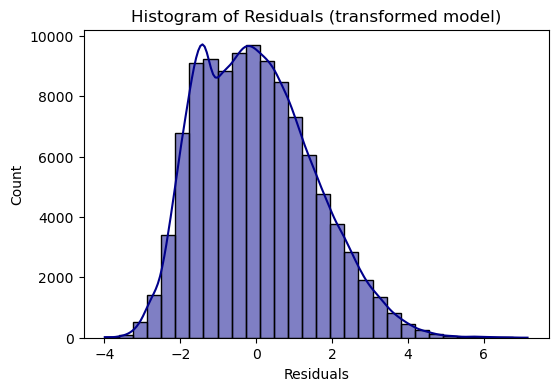

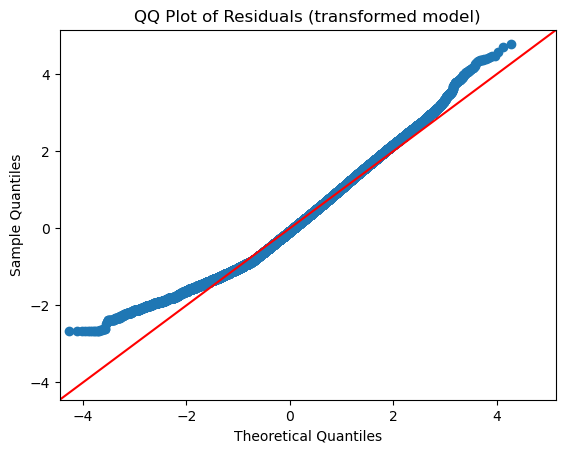

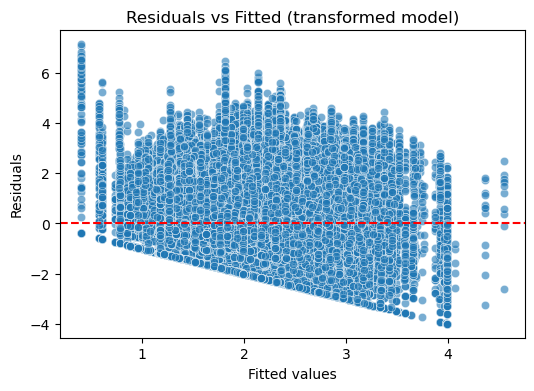

In [ ]:
# 1.calculate the mean of variables respectively
means = df[['total_flow', 'average_flow', 'median_age', 'percent_male', 'pop_density']].mean().reset_index()
means.columns = ['Variable', 'Mean']
print(means)

# 2. show the distribution of Y1, X1, X2, X3
plt.figure(figsize=(7,4))
sns.histplot(df['total_flow'], kde=True, bins=30, color='green')
plt.title('Distribution of total_flow')
plt.xlabel('total_flow')
plt.ylabel('frequency')
plt.show()

plt.figure(figsize=(15,4))
for i, col in enumerate(['median_age', 'percent_male', 'pop_density']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 3. transform Y1 and X3 into log(1+Y1) and log(1+X3)
df["total_flow_log"] = np.log1p(df["total_flow"])
df["pop_density_log"] = np.log1p(df["pop_density"])

# 4. check linearity (scatter plot and LOESS line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age", "percent_male", "pop_density_log"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="total_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(1+Y1) vs {var}")

plt.tight_layout()
plt.show()

# 5. transform variables according to the results in 4
df["median_age_centered_sq"] = np.power(df["median_age"] - 40, 2)
df["percent_male_abs"] = np.abs(df["percent_male"] - 0.5)
df["pop_density_log_cub"] = np.power(df["pop_density_log"], 3) 

# 6. check linearity again (scatter plot and LOESS line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age_centered_sq", "percent_male_abs", "pop_density_log_cub"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="total_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(1+Y1) vs {var}")

plt.tight_layout()
plt.show()

# 7. establish a multiple linear regression model
X_total = df[["median_age_centered_sq", "percent_male_abs", "pop_density_log_cub"]]
X_total = sm.add_constant(X_total)  
Y1_log = df["total_flow_log"]

model1 = sm.OLS(Y1_log, X_total).fit(cov_type='HC3')
print(model1.summary())

# 8. check normality of residuals (histogram and Q–Q plot)
residuals1 = model1.resid
fitted1 = model1.fittedvalues

plt.figure(figsize=(6,4))
sns.histplot(residuals1, kde=True, color='darkblue', bins=30)
plt.title("Histogram of Residuals (transformed model)")
plt.xlabel("Residuals")
plt.show()

sm.qqplot(residuals1, line='45', fit=True)
plt.title("QQ Plot of Residuals (transformed model)")
plt.show()

# 9. check homoscedasticity
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted1, y=residuals1, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (transformed model)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

For model 1, histograms are used to check whether distributions of independent and dependent variables are normal.

The distributions of X1, X2 are approximately normal distribution, while the distributions of Y1 and X3 are right-skewed distribution, so transform Y1 and X3 into log(1+Y1) and log(1+X3). Then Assuming that the independent and dependent variables satisfy the linearity, establish a multiple linear regression model: log⁡(1+Y1)= β_0+β_1 X_1+β_2 X_2+β_3 log(1+X_3)+ε. 
By using linear regression to analyze effects of independent variables on dependent variable, there are four assumptions that should be satisfied and samples independence is considered automatically satisfied based on the collected data, so check linearity, normality of residuals, homoscedasticity respectively. Firstly, drawing scatter plot and LOESS line to check the linearity. According to the original shape of LOESS line, the direction of transforming variables is clear, which can be followed to make the LOESS line approximately a straight line, then the linearity between transformed independent and dependent variables exists.

After this, a new multiple linear regression model can be established: log⁡(Y_1+1)=β_0+β_1 〖(X_1-40)〗^2+β_2 |X_2-0.5|+β_3 [log(〖1+X〗_3)]^3+ε. Secondly, using the histogram and Q-Q plot of residuals to check the normality of residuals, and they both confirms the distribution of residuals are normal. Finally, utilizing scatter plot to check the homoscedasticity. 

The residuals’ points above the reference line distribute randomly while those below show discernible funnel shapes. Therefore, heteroscedasticity-robust standard errors (HC3) were applied in model establishment.


Multiple Linear Congression 2 (Model 2: Y2-average_flow, X1-median_age, X2-percent_male, X3-pop_density)

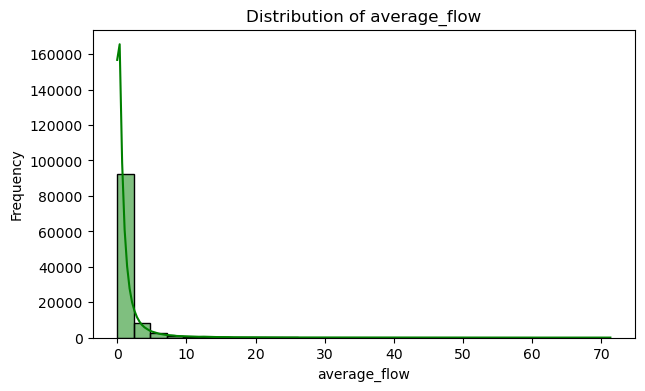

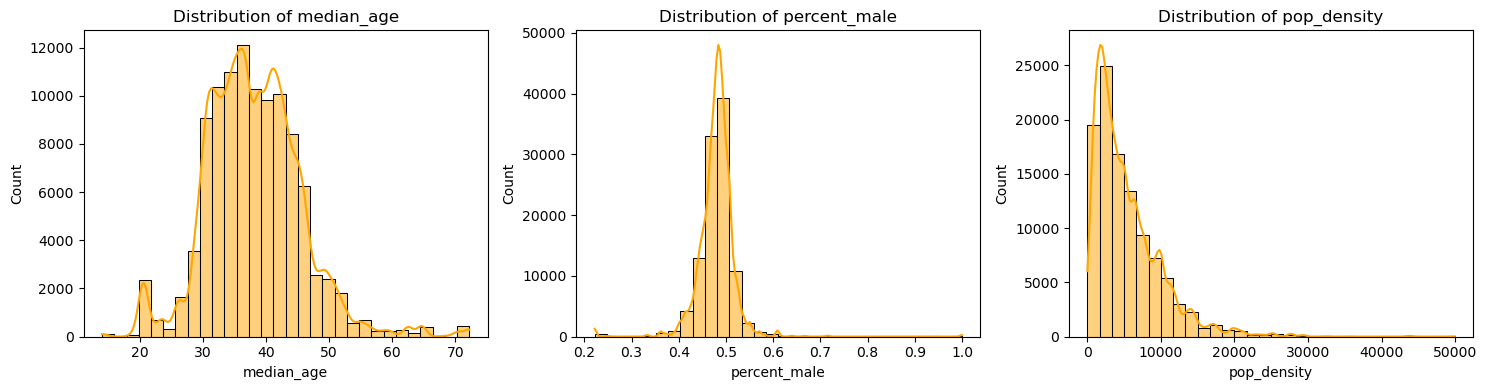

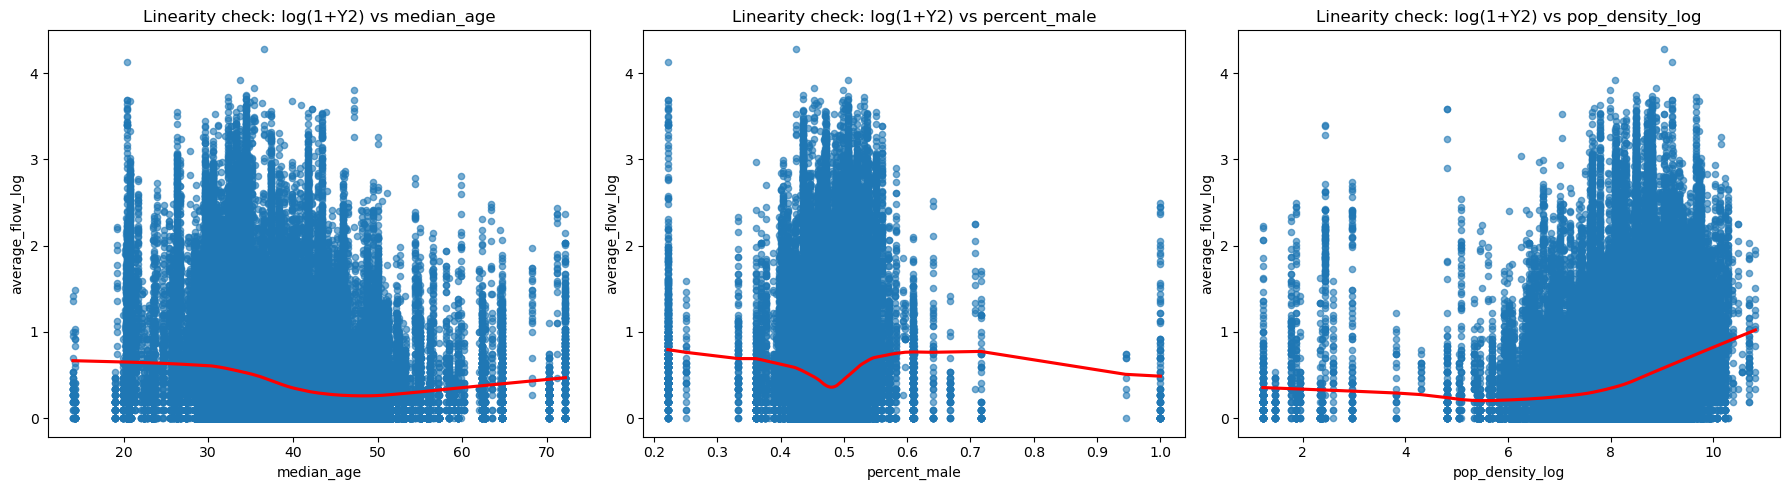

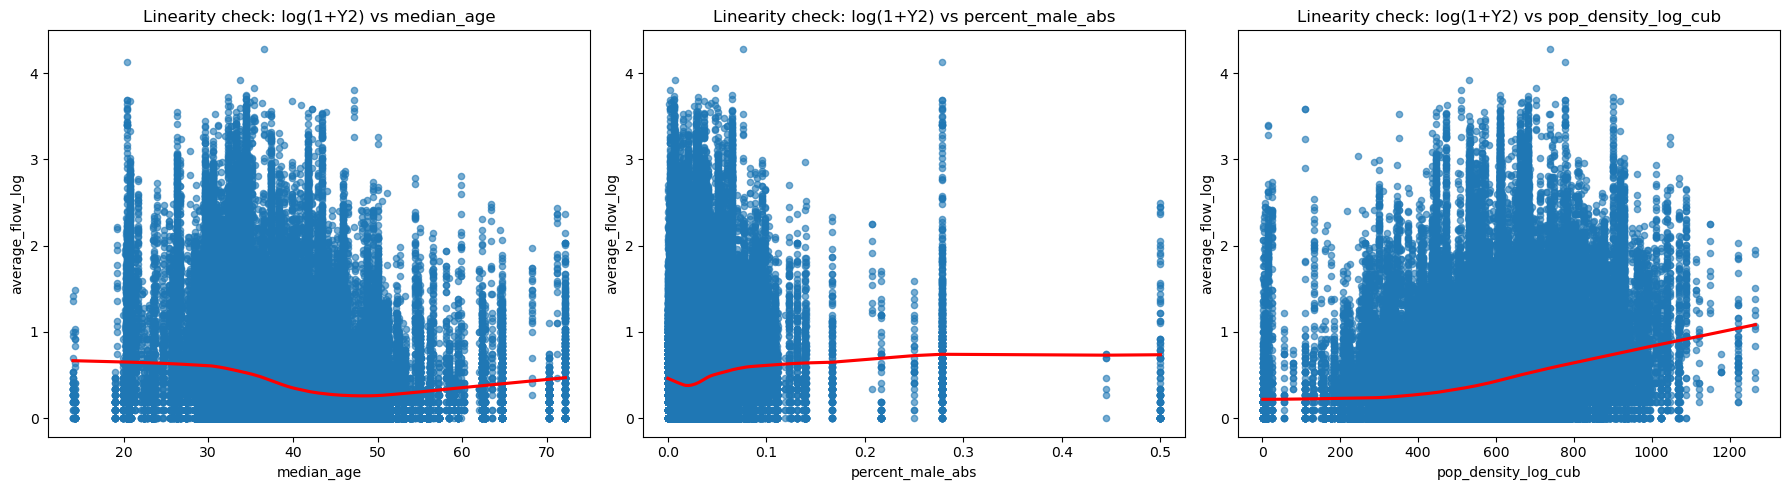

                            OLS Regression Results                            
Dep. Variable:       average_flow_log   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     3496.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:50:54   Log-Likelihood:                -89375.
No. Observations:              105918   AIC:                         1.788e+05
Df Residuals:                  105914   BIC:                         1.788e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4896    

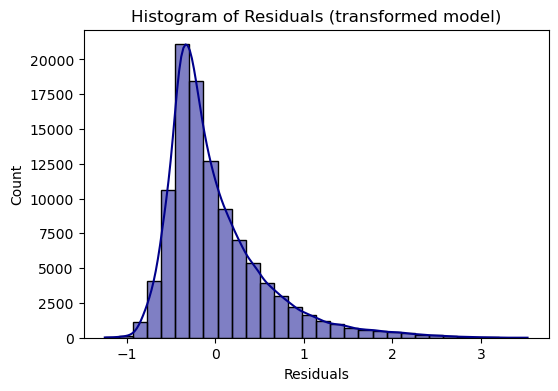

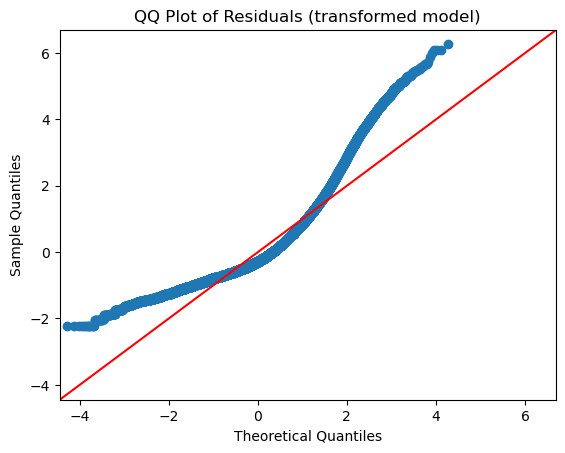

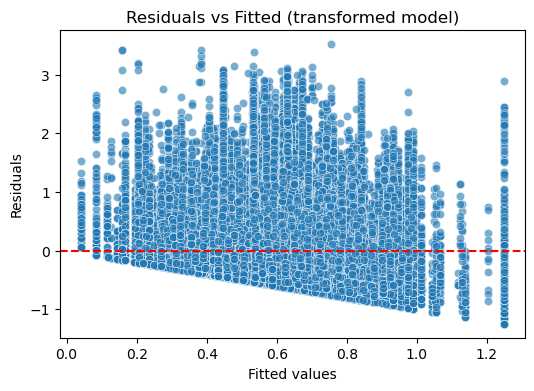

In [ ]:
# 1.show the distribution of Y2, X1, X2, X3 respectively
plt.figure(figsize=(7,4))
sns.histplot(df['average_flow'], kde=True, bins=30, color='green')
plt.title('Distribution of average_flow')
plt.xlabel('average_flow')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15,4))
for i, col in enumerate(['median_age', 'percent_male', 'pop_density']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 2. transform Y2 and X3 into log(1+Y2) and log(1+X3)
df["average_flow_log"] = np.log1p(df["average_flow"])     
df["pop_density_log"] = np.log1p(df["pop_density"])

# 3. check linearity (scatter plot and LOESS line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age", "percent_male", "pop_density_log"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="average_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(1+Y2) vs {var}")

plt.tight_layout()
plt.show()

# 4. transform variables according to the results in 3
df["percent_male_abs"] = np.abs(df["percent_male"] - 0.5) 
df["pop_density_log_cub"] = np.power(df["pop_density_log"], 3) 

# 5. check linearity again (scatter plot and regression line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age", "percent_male_abs", "pop_density_log_cub"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="average_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(1+Y2) vs {var}")

plt.tight_layout()
plt.show()

# 6. establish a multiple linear regression model
X_avg = df[["median_age", "percent_male_abs", "pop_density_log_cub"]]
X_avg = sm.add_constant(X_avg) 
Y2_log = df["average_flow_log"]

model2 = sm.OLS(Y2_log, X_avg).fit(cov_type='HC3')
print(model2.summary())


# 7. check normality of residuals (histogram and Q–Q plot)
residuals2 = model2.resid
fitted2 = model2.fittedvalues

plt.figure(figsize=(6,4))
sns.histplot(residuals2, kde=True, color='darkblue', bins=30)
plt.title("Histogram of Residuals (transformed model)")
plt.xlabel("Residuals")
plt.show()

sm.qqplot(residuals2, line='45', fit=True)
plt.title("QQ Plot of Residuals (transformed model)")
plt.show()

# 8. check homoscedasticity
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted2, y=residuals2, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (transformed model)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

The flow of establishing model 2 is the same as that in model 1, so it won't be explained in details anymore.

VIF check:

The output OLS regression results read “The condition number is large, 1.82e+04. This might indicate that there are strong multicollinearity or other numerical problems.” To confirm there is no multicollinearity among independent variables, VIF check is applied. If VIF≈1, then the independent variable is essentially uncorrelated with other predictors. If VIF ranges from 1 to 5, then there is moderate correlation, which is generally acceptable. If VIF > 5, then there is moderate to high multicollinearity. If VIF > 10, then high multicollinearity, which may affect standard errors and t-values.

In [ ]:
# check multicollinearity among indepedent variables
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_total = df[["median_age_centered_sq", "percent_male_abs", "pop_density_log_cub"]]
X_total = sm.add_constant(X_total)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_total.columns
vif_data["VIF"] = [variance_inflation_factor(X_total.values, i) for i in range(X_total.shape[1])]

print(vif_data)

                 Variable        VIF
0                   const  11.585149
1  median_age_centered_sq   1.173928
2        percent_male_abs   1.171225
3     pop_density_log_cub   1.002584
